In [2]:
import sys
import matplotlib
import matplotlib.pyplot as plt

import koplot
koplot.use_korean()

from dates import DateData
from model import train, translate

[koplot] 한글 폰트 적용: NanumGothic


In [3]:
data = DateData(8000)
data.SRC_LEN
for s, t in data.pairs[0:7]:
    print(s, t)

2027년 7월 25일 2027-07-25
2001년 5월 17일 2001-05-17
16/05/2012 2012-05-16
April 17, 2018 2018-04-17
25 March 2009 2009-03-25
May 18, 2019 2019-05-18
24 February 2009 2009-02-24


In [4]:
enc, dec = train(data)

  epoch 0  loss 1.849  (2.7s)
  epoch 1  loss 0.993  (4.9s)
  epoch 2  loss 0.551  (7.2s)
  epoch 3  loss 0.227  (9.5s)
  epoch 4  loss 0.051  (12.1s)
  epoch 5  loss 0.016  (14.5s)


In [5]:
translate(enc, dec, data, "28 July 2026")
translate(enc, dec, data, "17 October 2028")

('2028-10-17',
 array([[1.45836892e-02, 2.68666111e-02, 1.99153204e-04, 6.51557883e-03,
         6.72320090e-03, 5.06652147e-03, 2.65926123e-02, 1.34115980e-03,
         6.98942240e-05, 9.99611439e-05, 9.44773637e-05, 2.61929065e-01,
         3.84752214e-01, 9.60445106e-02, 1.57036215e-01],
        [1.02798687e-03, 1.54826487e-03, 5.93868390e-05, 3.18563922e-04,
         2.95377453e-04, 1.50301878e-03, 1.22389803e-03, 1.07756183e-04,
         1.30175704e-05, 7.40873247e-06, 5.83355541e-06, 4.69460967e-04,
         7.69744933e-01, 2.04501465e-01, 1.80293266e-02],
        [7.62790150e-04, 1.85689307e-03, 6.69249202e-05, 1.64472774e-04,
         1.49474086e-04, 5.36766194e-04, 3.10557778e-04, 3.78420191e-05,
         7.00749024e-06, 8.91819218e-06, 1.63505410e-05, 1.51436790e-04,
         1.55352443e-01, 8.01725507e-01, 3.84962372e-02],
        [5.81239728e-05, 1.00663958e-04, 4.47428374e-06, 8.83624598e-05,
         1.02528499e-03, 1.82223786e-03, 5.04693773e-04, 1.00949001e-04,
        

In [6]:
translate(enc, dec, data, "2026.07.32")[0]

'2026-07-20'

## 시각화로 보기


In [7]:
from viz import plot_alignment, print_weight_row

In [13]:
src = "28 July 2026",
pred, A = translate(enc, dec, data, "28 July 2026")


<Axes: title={'center': "('28 July 2026',)  →  2026-07-28"}, xlabel='입력', ylabel='출력'>

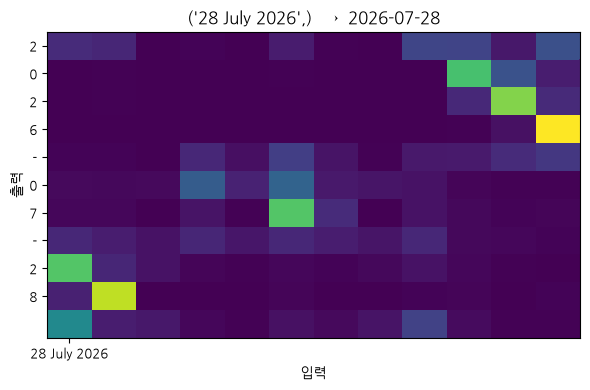

In [15]:
plot_alignment(src=src, pred=pred, A=A)

In [17]:
print_weight_row(src, pred, A, out_idx=5)

출력 '0' (출력 5번째)의 어텐션 가중치 — 합 = 0.93
  입력[ 0] '28 July 2026' 0.02  █


In [ ]:
print